# pathsim-flight: JSBSim as a PathSim Block

[pathsim-flight](https://github.com/pathsim/pathsim-flight) bridges
[JSBSim](https://github.com/JSBSim-Team/jsbsim) and [PathSim](https://github.com/pathsim/pathsim).
It provides:

| Class | Description |
|-------|-------------|
| `JSBSimWrapper` | Wraps a JSBSim FDM as a discrete-time PathSim `Wrapper` block. Inputs are control surface commands; outputs are state properties. |
| `ISAtmosphere` | International Standard Atmosphere model: given geometric altitude and temperature offset, returns pressure, density, temperature, and speed of sound. |
| Airspeed utilities | `CAStoTAS`, `TAStoEAS`, `MachtoCAS`, … |

### Install

```bash
pip install pathsim
pip install git+https://github.com/pathsim/pathsim-flight.git
```

## 1. Imports

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import jsbsim
import pathsim
import pathsim_flight

from pathsim import Simulation, Connection
from pathsim.blocks import Scope, Constant
from pathsim_flight import JSBSimWrapper, ISAtmosphere
from pathsim_flight.utils.airspeed_conversions import CAStoTAS, TAStoCAS

matplotlib.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.4})

# Suppress JSBSim console output globally
jsbsim.FGJSBBase().debug_lvl = 0

print(f"JSBSim version        : {jsbsim.__version__}")
print(f"PathSim version       : {pathsim.__version__}")
print(f"pathsim-flight version: {pathsim_flight.__version__}")

JSBSim version        : 1.2.4
PathSim version       : 0.20.0
pathsim-flight version: 0.1.1.dev2+g0b0e9b4c2


## 2. International Standard Atmosphere

`ISAtmosphere` is a PathSim `Function` block.  Its two inputs are:

* **Port 0** – geometric altitude [m]
* **Port 1** – temperature offset from ISA standard day [K]  (0 = standard day)

Its four outputs are pressure [Pa], density [kg/m³], temperature [K], and speed of sound [m/s].

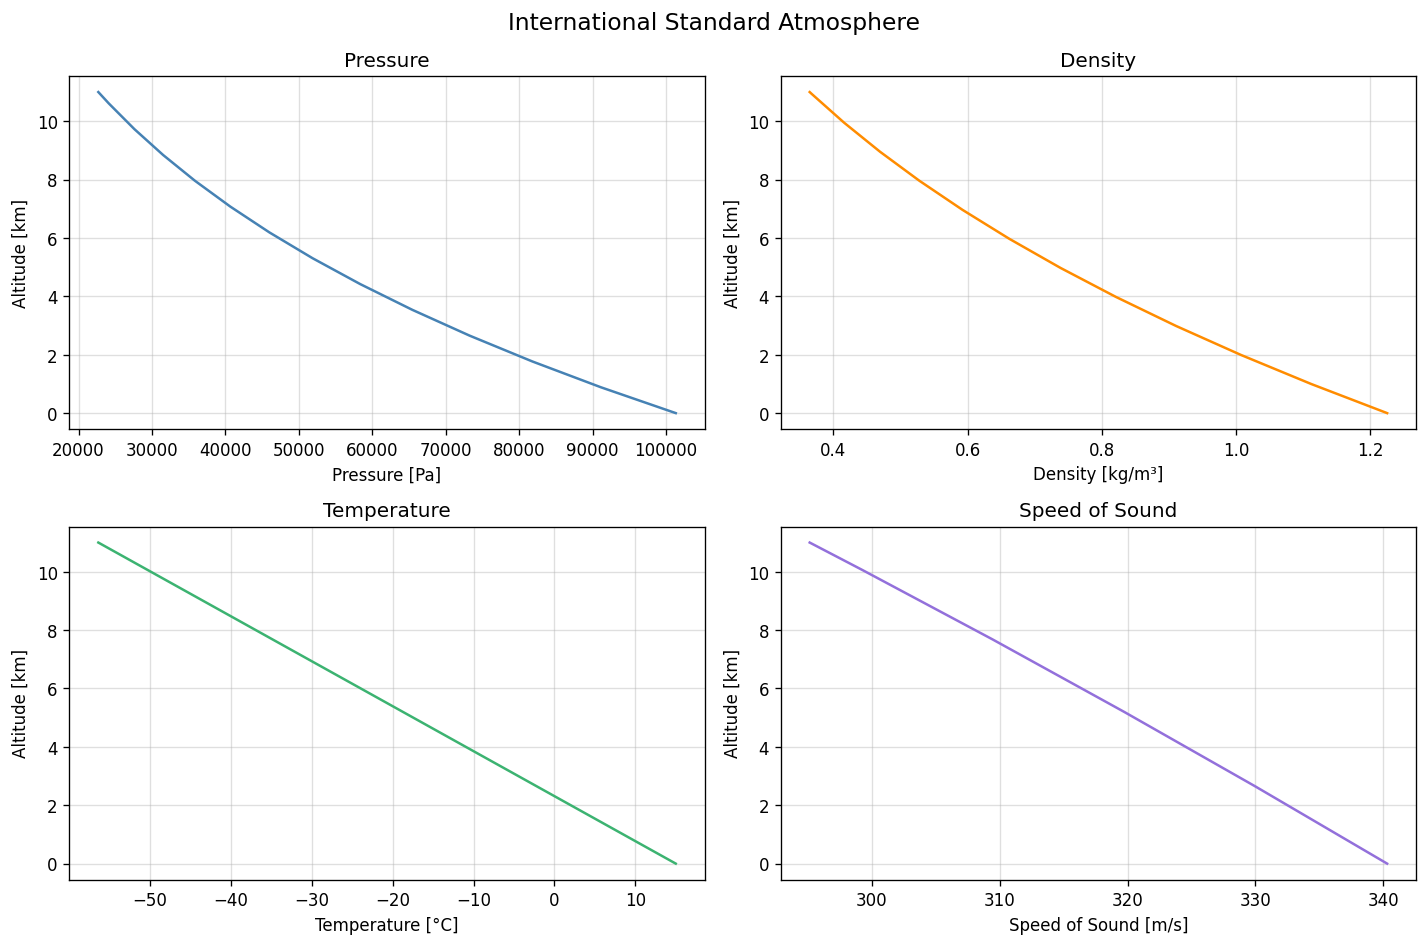

Sea-level pressure     : 101325.0 Pa
Sea-level temperature  : 15.00 °C
Sea-level speed of snd : 340.294 m/s


In [2]:
from pathsim.blocks import Source

# Sweep altitude from 0 to 11 000 m (tropopause)
alt_max_m = 11_000.0
altitudes_m = np.linspace(0, alt_max_m, 200)

isa = ISAtmosphere()
temp_offset = Constant(0.0)   # standard day

# We will evaluate standalone (not in a Simulation) for a quick sweep
pressures   = []
densities   = []
temperatures = []
speeds_of_sound = []

for alt in altitudes_m:
    result = isa._eval(alt, 0.0)
    pressures.append(result[0])
    densities.append(result[1])
    temperatures.append(result[2])
    speeds_of_sound.append(result[3])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('International Standard Atmosphere', fontsize=14)

axes[0, 0].plot(pressures, altitudes_m / 1000, color='steelblue')
axes[0, 0].set_xlabel('Pressure [Pa]')
axes[0, 0].set_ylabel('Altitude [km]')
axes[0, 0].set_title('Pressure')

axes[0, 1].plot(densities, altitudes_m / 1000, color='darkorange')
axes[0, 1].set_xlabel('Density [kg/m³]')
axes[0, 1].set_ylabel('Altitude [km]')
axes[0, 1].set_title('Density')

axes[1, 0].plot(np.array(temperatures) - 273.15, altitudes_m / 1000, color='mediumseagreen')
axes[1, 0].set_xlabel('Temperature [°C]')
axes[1, 0].set_ylabel('Altitude [km]')
axes[1, 0].set_title('Temperature')

axes[1, 1].plot(speeds_of_sound, altitudes_m / 1000, color='mediumpurple')
axes[1, 1].set_xlabel('Speed of Sound [m/s]')
axes[1, 1].set_ylabel('Altitude [km]')
axes[1, 1].set_title('Speed of Sound')

plt.tight_layout()
plt.savefig('isa_atmosphere.png', bbox_inches='tight')
plt.show()

print(f"Sea-level pressure     : {pressures[0]:.1f} Pa")
print(f"Sea-level temperature  : {temperatures[0] - 273.15:.2f} °C")
print(f"Sea-level speed of snd : {speeds_of_sound[0]:.3f} m/s")

## 3. Airspeed conversions

`pathsim_flight` provides utility functions to convert between CAS, TAS, EAS, and Mach.

In [3]:
cas_kts = 120.0  # Calibrated Airspeed [kts]

altitudes_ft = [0, 5000, 10000, 20000, 30000, 40000]

print(f"{'Altitude [ft]':>16} {'CAS [kts]':>10} {'TAS [kts]':>10} {'TAS/CAS':>8}")
print('-' * 50)
for alt_ft in altitudes_ft:
    alt_m = alt_ft * 0.3048
    p, rho, T, a = isa._eval(alt_m, 0.0)
    # CAS → TAS conversion (using sea-level standard density)
    rho_sl = 1.225  # kg/m³ sea-level standard
    tas_kts = cas_kts * (rho_sl / rho) ** 0.5
    print(f"{alt_ft:>16} {cas_kts:>10.1f} {tas_kts:>10.1f} {tas_kts/cas_kts:>8.3f}")

   Altitude [ft]  CAS [kts]  TAS [kts]  TAS/CAS
--------------------------------------------------
               0      120.0      120.0    1.000
            5000      120.0      129.3    1.077
           10000      120.0      139.6    1.164
           20000      120.0      164.3    1.370
           30000      120.0      196.0    1.634
           40000      120.0      241.4    2.012


## 4. JSBSimWrapper – embedding JSBSim in a PathSim diagram

`JSBSimWrapper` wraps a JSBSim FDM as a discrete-time `Wrapper` block.

Key parameters:

| Parameter | Description |
|-----------|-------------|
| `T` | Discrete-time step for JSBSim [s] |
| `input_properties` | List of JSBSim property names for block inputs |
| `output_properties` | List of JSBSim property names for block outputs |
| `aircraft_model` | Aircraft directory name (e.g. `'c172p'`) |
| `trim_airspeed` | KCAS for trim |
| `trim_altitude` | Altitude [ft] for trim |

Below we build a **closed-loop pitch-hold autopilot** using:

* A `JSBSimWrapper` for the Cessna 172P dynamics.
* A `Constant` block to provide a pitch reference.
* A simple proportional controller (`Function` block).

In [4]:
from pathsim.blocks import Function, Amplifier, Adder

# ---------- Parameters ----------
AIRCRAFT     = 'c172p'
ALT_FT       = 5000.0    # trim altitude [ft]
AIRSPEED_KTS = 90.0      # trim KCAS
SIM_DUR      = 30.0      # simulation duration [s]
DT           = 1 / 60    # JSBSim time step [s]
Kp           = 0.5       # proportional gain [elevator/rad]
PITCH_REF    = 3.0       # pitch reference [deg]
# --------------------------------

# Flight dynamics model (JSBSim inside a PathSim block)
aircraft_block = JSBSimWrapper(
    T=DT,
    input_properties=['fcs/elevator-cmd-norm'],        # elevator input
    output_properties=[
        'attitude/theta-deg',     # pitch angle
        'position/h-sl-ft',       # altitude
        'velocities/vc-kts',      # calibrated airspeed
        'aero/alpha-deg',         # angle of attack
    ],
    aircraft_model=AIRCRAFT,
    trim_airspeed=AIRSPEED_KTS,
    trim_altitude=ALT_FT,
    trim_gamma=0.0,
)

# Reference pitch angle
pitch_ref = Constant(PITCH_REF)                        # deg

# Error = reference − actual pitch
pitch_error = Adder('+-')

# Proportional controller: elevator = Kp * error (deg → normalised)
controller = Amplifier(Kp / 90.0)    # /90 to stay roughly in [-1, 1]

# Record pitch, altitude, and airspeed
scope_flight = Scope(labels=['pitch_deg', 'alt_ft', 'vc_kts', 'alpha_deg'])
scope_ctrl   = Scope(labels=['elevator_cmd', 'pitch_error'])

sim_ap = Simulation(
    blocks=[pitch_ref, aircraft_block, pitch_error, controller, scope_flight, scope_ctrl],
    connections=[
        # Autopilot loop
        Connection(pitch_ref, pitch_error, scope_ctrl[1]),      # reference → error adder
        Connection(aircraft_block[0], pitch_error[1]),           # actual pitch → error adder
        Connection(pitch_error, controller, scope_ctrl[0]),      # error → gain
        Connection(controller, aircraft_block),                  # elevator command → FDM
        # Scopes
        Connection(aircraft_block[0], scope_flight[0]),          # pitch
        Connection(aircraft_block[1], scope_flight[1]),          # altitude
        Connection(aircraft_block[2], scope_flight[2]),          # airspeed
        Connection(aircraft_block[3], scope_flight[3]),          # AoA
    ],
    dt=DT
)

sim_ap.run(SIM_DUR)

print("Autopilot simulation complete")



     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174
    WingSpan: 35.8
    Incidence: 0
    Chord: 4.9
    H. Tail Area: 21.9
    H. Tail Arm: 15.7
    V. Tail Area: 16.5
    V. Tail Arm: 0
    Eyepoint (x, y, z): 37 , 0 , 48
    Ref Pt (x, y, z): 43.2 , 0 , 59.4
    Visual Ref Pt (x, y, z): 42.6 , 0 , 38.5

  Mass and Balance:
    baseIxx: 948 slug-ft2
    baseIyy: 1346 slug-ft2
    baseIzz: 1967 slug-ft2
    baseIxy: 0 slug-ft2
    baseIxz: -0 slug-ft2
    baseIyz: 0 slug-ft2
    Empty Weight: 

el                                   100      56     112    59.4           0           0           0
                                                                                                                                            
    Total:                            1880.0    42.1    -1.3    37.7      1524.5      1384.3      2525.6         3.3       -16.7         7.5

End of vehicle configuration loading.
-------------------------------------------------------------------------------
  Full Trim

  Trim successful
  Trim Results: 
       Angle of Attack:   1.29  wdot: -1.25e-04 Tolerance: 1e-03  Passed
              Throttle:   0.66  udot: -2.95e-05 Tolerance: 1e-03  Passed
            Pitch Trim:   0.13  qdot:  3.65e-09 Tolerance: 1e-04  Passed
            Roll Angle:   0.05  vdot: -1.11e-06 Tolerance: 1e-03  Passed
              Ailerons:   0.04  pdot: -5.65e-08 Tolerance: 1e-04  Passed
                Rudder:  -0.01  rdot:  2.17e-18 Tolerance: 1e-04  Passed
12:39:23 - I

12:39:23 - INFO - GRAPH (nodes: 6, edges: 10, alg. depth: 1, loop depth: 3, runtime: 0.109ms)


12:39:23 - INFO - STARTING -> TRANSIENT (Duration: 30.00s)


12:39:23 - INFO - --------------------   1% | 0.0s<0.2s | 7875.9 it/s


...

12:39:24 - INFO - ############--------  60% | 0.2s<0.1s | 8328.4 it/s


12:39:24 - INFO - ################----  80% | 0.2s<0.0s | 7888.6 it/s


12:39:24 - INFO - #################### 100% | 0.3s<--:-- | 7731.7 it/s


12:39:24 - INFO - FINISHED -> TRANSIENT (total steps: 1801, successful: 1801, runtime: 275.26 ms)


Autopilot simulation complete


## 5. Plot the results

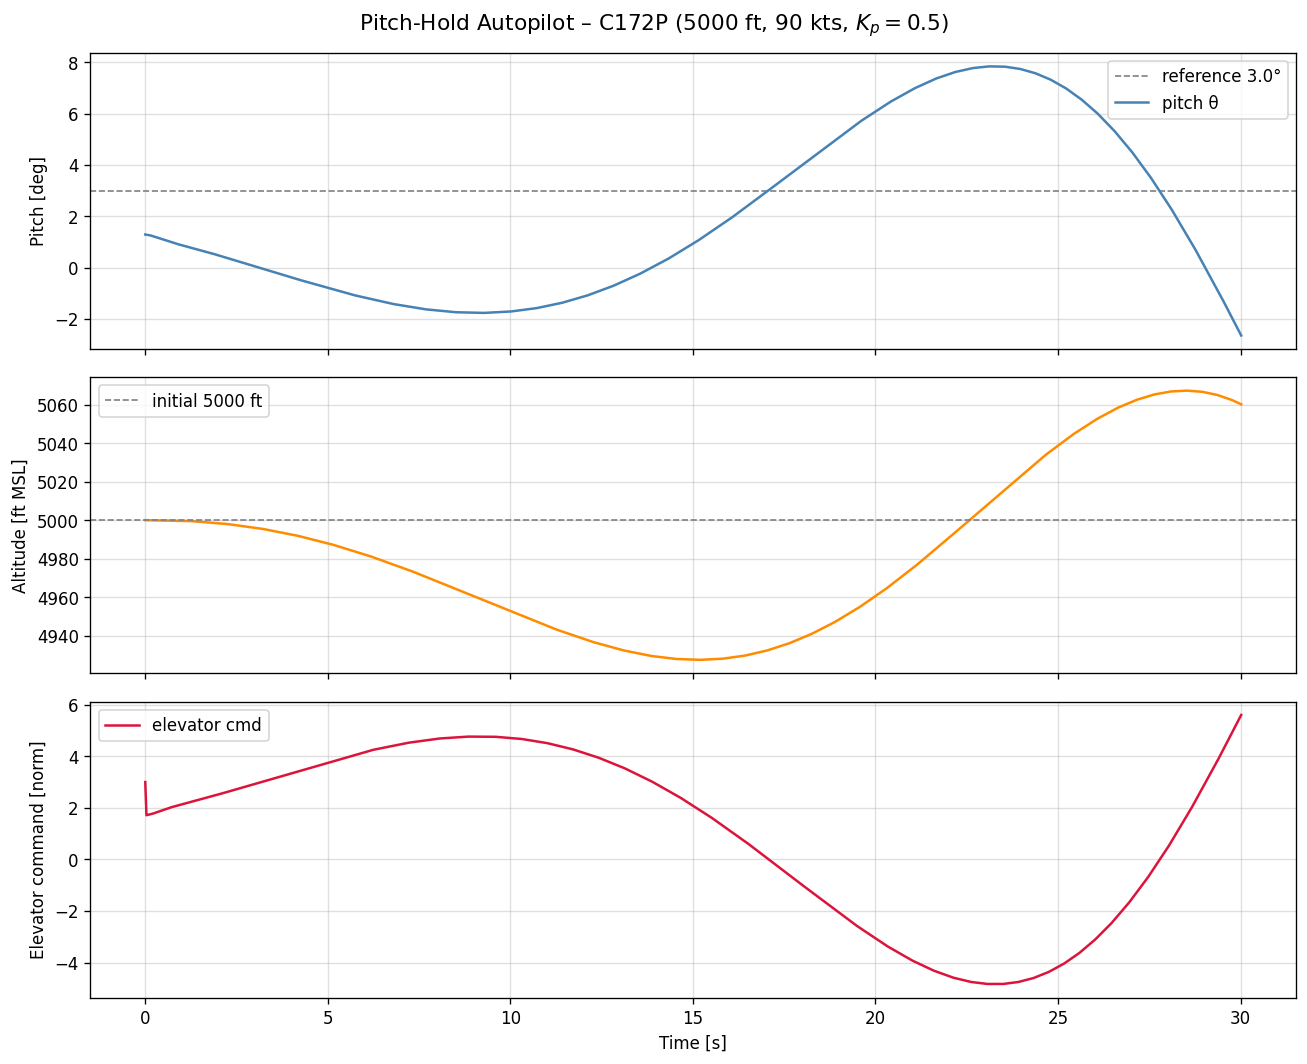

In [5]:
t_ap, flight_data = scope_flight.read()
pitch_ap, alt_ap, vc_ap, aoa_ap = flight_data[0], flight_data[1], flight_data[2], flight_data[3]
t_ctrl, ctrl_data = scope_ctrl.read()
elev_ap, err_ap = ctrl_data[0], ctrl_data[1]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.suptitle(
    f'Pitch-Hold Autopilot – {AIRCRAFT.upper()} '
    f'({ALT_FT:.0f} ft, {AIRSPEED_KTS:.0f} kts, $K_p={Kp}$)',
    fontsize=13
)

axes[0].axhline(PITCH_REF, color='grey', linestyle='--', linewidth=1.0,
                label=f'reference {PITCH_REF}°')
axes[0].plot(t_ap, pitch_ap, color='steelblue', linewidth=1.5, label='pitch θ')
axes[0].set_ylabel('Pitch [deg]')
axes[0].legend()

axes[1].plot(t_ap, alt_ap, color='darkorange', linewidth=1.5)
axes[1].axhline(ALT_FT, color='grey', linestyle='--', linewidth=1.0, label=f'initial {ALT_FT:.0f} ft')
axes[1].set_ylabel('Altitude [ft MSL]')
axes[1].legend()

axes[2].plot(t_ctrl, elev_ap, color='crimson', linewidth=1.5, label='elevator cmd')
axes[2].set_ylabel('Elevator command [norm]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()

plt.tight_layout()
plt.savefig('autopilot_pitch_hold.png', bbox_inches='tight')
plt.show()

## 6. Angle-of-attack and airspeed

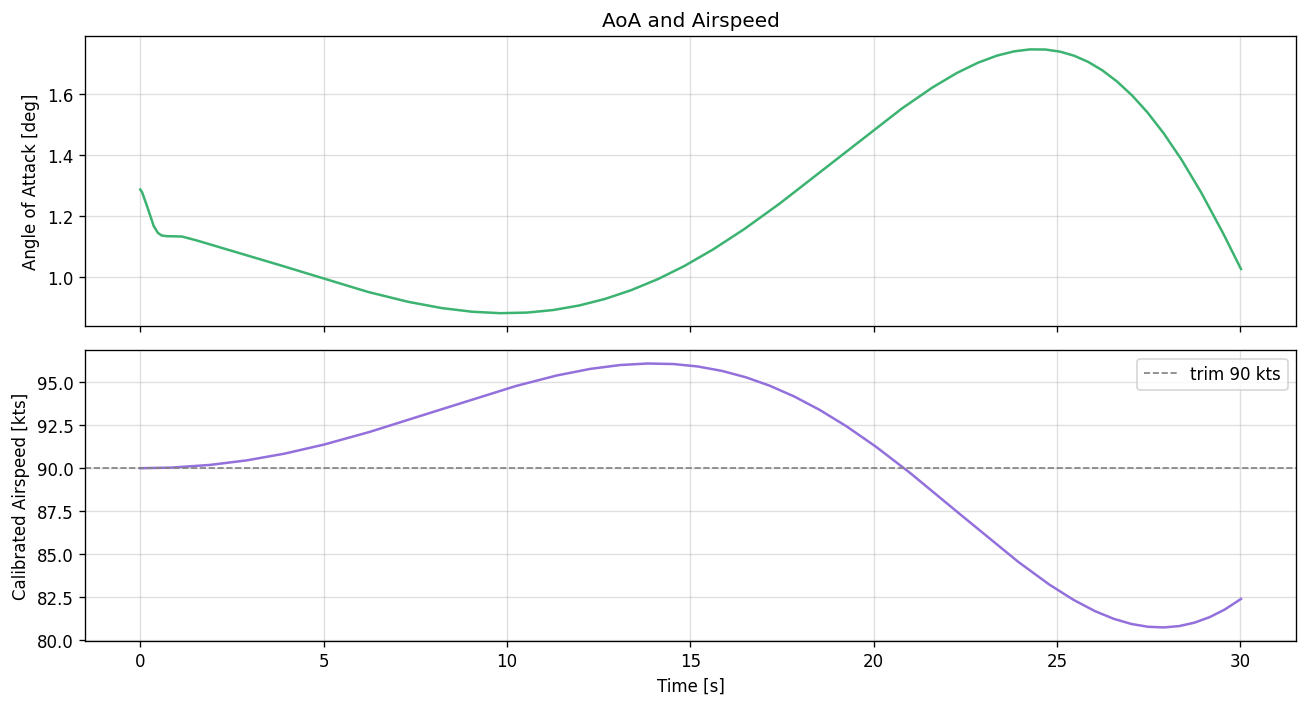

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(t_ap, aoa_ap, color='mediumseagreen', linewidth=1.5)
axes[0].set_ylabel('Angle of Attack [deg]')
axes[0].set_title('AoA and Airspeed')

axes[1].plot(t_ap, vc_ap, color='mediumpurple', linewidth=1.5)
axes[1].axhline(AIRSPEED_KTS, color='grey', linestyle='--', linewidth=1.0,
                label=f'trim {AIRSPEED_KTS:.0f} kts')
axes[1].set_ylabel('Calibrated Airspeed [kts]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()

plt.tight_layout()
plt.savefig('autopilot_aoa_airspeed.png', bbox_inches='tight')
plt.show()

## Summary

In this notebook you:

* Used `ISAtmosphere` to plot ISA profiles from sea level to the tropopause.
* Demonstrated airspeed-conversion utilities from `pathsim_flight`.
* Built a **closed-loop pitch-hold autopilot** using `JSBSimWrapper` embedded in a PathSim
  block diagram alongside a proportional controller.

The same pattern can be extended to:

* Multi-axis controllers (pitch + roll + yaw).
* Altitude-hold and airspeed-hold outer loops.
* Hardware-in-the-loop (HIL) testing by replacing the `JSBSimWrapper` with real sensor data.